# Exploración de los datos procesados por trabajador
Este notebook analiza los archivos `combined_features_1min.csv` generados para cada trabajador.

Incluye tamaño de los archivos, número de ventanas, columnas, rango temporal, actividades, ejemplos y datos faltantes.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

## Localizar los archivos
El notebook busca primero en la carpeta actual y después en `new`, por lo que funciona tanto si se ejecuta desde `new` como desde la raíz del proyecto.

In [2]:
candidate_roots = [Path.cwd(), Path.cwd() / 'new']
root_dir = next((root for root in candidate_roots if (root / 'W00').is_dir()), None)
if root_dir is None:
    raise FileNotFoundError('No se encontraron las carpetas W00-W04 desde la ubicacion actual.')

worker_files = {}
for worker_number in range(5):
    worker = f'W{worker_number:02d}'
    path = root_dir / worker / 'PROCESSED' / 'combined_features_1min.csv'
    if path.exists():
        worker_files[worker] = path

if not worker_files:
    raise FileNotFoundError('No se encontraron archivos combined_features_1min.csv.')

data = {worker: pd.read_csv(path) for worker, path in worker_files.items()}
print(f'Carpeta de datos: {root_dir}')
print(f'Trabajadores encontrados: {list(data)}')
print(f'Trabajadores ausentes: {[f"W{i:02d}" for i in range(5) if f"W{i:02d}" not in data]}')

Carpeta de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new
Trabajadores encontrados: ['W00', 'W01', 'W02', 'W03', 'W04']
Trabajadores ausentes: []


## Resumen general
Cada fila representa una ventana temporal de un minuto. `DateTime` contiene únicamente la hora de inicio de la ventana.

In [3]:
summary_rows = []
for worker, df in data.items():
    file_path = worker_files[worker]
    summary_rows.append({
        'Trabajador': worker,
        'Archivo': file_path.name,
        'Tamaño (KB)': round(file_path.stat().st_size / 1024, 2),
        'Filas / ventanas': len(df),
        'Columnas': len(df.columns),
        'Primera hora': df['DateTime'].iloc[0] if len(df) else '',
        'Última hora': df['DateTime'].iloc[-1] if len(df) else '',
        'HR_valid = 1': int((df['HR_valid'] == 1).sum()) if 'HR_valid' in df else 0,
        'HR_valid = 0': int((df['HR_valid'] == 0).sum()) if 'HR_valid' in df else 0,
    })

summary = pd.DataFrame(summary_rows)
summary

,Trabajador,Archivo,Tamaño (KB),Filas / ventanas,Columnas,Primera hora,Última hora,HR_valid = 1,HR_valid = 0
0,W00,combined_features_1min.csv,25.80,104,16,07:24:04,09:07:04,104,0
1,W01,combined_features_1min.csv,105.89,637,16,07:50:23,18:26:25,120,517
2,W02,combined_features_1min.csv,99.49,603,16,07:59:30,18:27:25,103,500
3,W03,combined_features_1min.csv,99.95,407,16,08:05:30,15:39:53,403,4
4,W04,combined_features_1min.csv,87.67,562,16,09:07:31,18:28:33,54,508


## Estructura y ejemplos
Se muestran las columnas disponibles y las primeras filas de cada trabajador.

In [4]:
for worker, df in data.items():
    print(f'\n--- {worker} ---')
    print('Columnas:', list(df.columns))
    display(df.head(3))


--- W00 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1754893444134277584,07:24:04,Fuera de jornada,1,-0.413269,0.249098,2.980,0.232833,0.230584,21,101.802302,74.056198,29.487179,79.261563,99.173554,62.695925
1,1754893504139173426,07:25:04,Fuera de jornada,1,-0.328069,0.224857,2.404,0.158183,0.293727,16,75.981805,100.685571,6.741573,89.854735,100.334448,47.732697
2,1754893564142679638,07:26:04,Fuera de jornada,1,-0.290664,0.440643,8.627,0.278627,0.139056,24,64.144013,54.235862,16.091954,87.782008,96.774194,61.412487



--- W01 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1754895023517919850,07:50:23,Fuera de jornada,1,-0.165954,0.298329,3.100,0.116529,0.259471,20.0,69.874242,25.701079,7.792208,77.809367,87.463557,62.111801
1,1754895083518036155,07:51:23,Fuera de jornada,1,-0.146203,0.285583,3.022,0.102923,0.193339,12.0,62.205520,33.126022,13.043478,70.360009,84.388186,62.047570
2,1754895143519312400,07:52:23,Fuera de jornada,1,-0.122771,0.341858,3.300,0.131924,0.323322,16.0,67.586874,20.585929,1.219512,82.658346,99.009901,67.567568



--- W02 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1754895570929669084,07:59:30,Fuera de jornada,1,-0.181537,0.220353,1.893,0.081505,0.146989,27.0,40.702065,22.608801,1.315789,80.746644,91.743119,71.005917
1,1754895630936259773,08:00:30,Preparacion de muestras,0,-0.148201,0.236072,2.107,0.077686,0.189479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1754895690940196106,08:01:30,Preparacion de muestras,0,-0.121094,0.241538,2.104,0.072997,0.172535,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- W03 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1754895930522605954,08:05:30,Preparacion de muestras,0,-0.169415,0.177942,2.538,0.060361,0.252703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1754895990526515667,08:06:30,Preparacion de muestras,0,-0.141780,0.204048,2.691,0.061732,0.266840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1754896050528624780,08:07:30,Preparacion de muestras,0,-0.117349,0.167778,2.523,0.041917,0.240699,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- W04 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1754899651747291774,09:07:31,Preparacion de muestras,0,-0.162003,0.308379,3.753,0.121330,0.260566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1754899711748838850,09:08:31,Preparacion de muestras,0,-0.170957,0.376067,4.532,0.170635,0.345270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1754899771750243540,09:09:31,Preparacion de muestras,0,-0.162938,0.303221,3.165,0.118480,0.387136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Actividades registradas
La actividad se asigna según los horarios descritos en `Readme.txt`. La tabla muestra cuántas ventanas tiene cada categoría.

In [5]:
activity_counts = []
for worker, df in data.items():
    counts = df['Actividad'].value_counts(dropna=False)
    for activity, count in counts.items():
        activity_counts.append({'Trabajador': worker, 'Actividad': activity, 'Ventanas': int(count)})

activity_table = pd.DataFrame(activity_counts)
activity_table.pivot(index='Actividad', columns='Trabajador', values='Ventanas').fillna(0).astype(int)

Trabajador,W00,W01,W02,W03,W04
Actividad,,,,,
Almuerzo,0,60,60,60,60
Colocacion de 12 paneles,0,290,290,156,290
Colocacion de 4 paneles,0,75,75,75,75
Desplazamiento de ida,0,45,45,45,45
Desplazamiento de regreso,0,37,38,0,39
Fuera de jornada,36,10,1,0,0
Preparacion de muestras,68,120,94,71,53


## Datos faltantes
Una celda vacía indica que la variable no pudo calcularse en esa ventana. No debe interpretarse como un valor numérico igual a cero.

`HR_valid = 1` significa que las variables agregadas derivadas de HR/RR (`SDNN`, `RMSSD`, `pNN50`, `HR_mean`, `HR_max` y `HR_min`) pudieron calcularse y son válidas. `HR_valid = 0` significa que falta información suficiente para calcularlas.

In [6]:
missing_rows = []
for worker, df in data.items():
    missing = df.isna() | df.astype('object').eq('')
    for column in df.columns:
        missing_rows.append({
            'Trabajador': worker,
            'Columna': column,
            'Celdas faltantes': int(missing[column].sum()),
            'Filas afectadas': int(missing[column].sum()),
            'Porcentaje de filas': round(100 * missing[column].sum() / len(df), 2) if len(df) else 0,
        })

missing_table = pd.DataFrame(missing_rows)
missing_table[missing_table['Celdas faltantes'] > 0].sort_values(['Trabajador', 'Celdas faltantes'], ascending=[True, False])

,Trabajador,Columna,Celdas faltantes,Filas afectadas,Porcentaje de filas
25,W01,ECG_missing_peaks,517,517,81.16
26,W01,SDNN,517,517,81.16
27,W01,RMSSD,517,517,81.16
28,W01,pNN50,517,517,81.16
29,W01,HR_mean,517,517,81.16
30,W01,HR_max,517,517,81.16
31,W01,HR_min,517,517,81.16
41,W02,ECG_missing_peaks,500,500,82.92
42,W02,SDNN,500,500,82.92
43,W02,RMSSD,500,500,82.92


In [7]:
hrv_columns = ['SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']
hrv_rows = []
for worker, df in data.items():
    available_hrv_columns = [column for column in hrv_columns if column in df.columns]
    rows_with_missing_hrv = df[available_hrv_columns].isna().any(axis=1) | df[available_hrv_columns].astype('object').eq('').any(axis=1)
    hrv_rows.append({
        'Trabajador': worker,
        'Ventanas totales': len(df),
        'Ventanas HR_valid = 1': int((df['HR_valid'] == 1).sum()),
        'Ventanas HR_valid = 0': int((df['HR_valid'] == 0).sum()),
        'Ventanas con alguna variable HRV faltante': int(rows_with_missing_hrv.sum()),
        'Porcentaje con HRV faltante': round(100 * rows_with_missing_hrv.mean(), 2) if len(df) else 0,
    })

hrv_summary = pd.DataFrame(hrv_rows)
hrv_summary

,Trabajador,Ventanas totales,Ventanas HR_valid = 1,Ventanas HR_valid = 0,Ventanas con alguna variable HRV faltante,Porcentaje con HRV faltante
0,W00,104,104,0,0,0.00
1,W01,637,120,517,517,81.16
2,W02,603,103,500,500,82.92
3,W03,407,403,4,4,0.98
4,W04,562,54,508,508,90.39


## Ventanas faltantes por actividad
Se agrupan las ventanas por trabajador y actividad para comprobar en qué actividades se concentra la falta de información de HR/RR.

In [8]:
activity_missing_rows = []
for worker, df in data.items():
    activity_group = df.groupby('Actividad', dropna=False)
    for activity, group in activity_group:
        total_windows = len(group)
        valid_windows = int((group['HR_valid'] == 1).sum())
        invalid_windows = int((group['HR_valid'] == 0).sum())
        activity_missing_rows.append({
            'Trabajador': worker,
            'Actividad': activity,
            'Ventanas totales': total_windows,
            'HR_valid = 1': valid_windows,
            'HR_valid = 0': invalid_windows,
            'Porcentaje faltante': round(100 * invalid_windows / total_windows, 2) if total_windows else 0,
        })

activity_missing_table = pd.DataFrame(activity_missing_rows)
activity_missing_table.sort_values(['Trabajador', 'Actividad'])

,Trabajador,Actividad,Ventanas totales,HR_valid = 1,HR_valid = 0,Porcentaje faltante
0,W00,Fuera de jornada,36,36,0,0.00
1,W00,Preparacion de muestras,68,68,0,0.00
2,W01,Almuerzo,60,0,60,100.00
3,W01,Colocacion de 12 paneles,290,29,261,90.00
4,W01,Colocacion de 4 paneles,75,3,72,96.00
5,W01,Desplazamiento de ida,45,0,45,100.00
6,W01,Desplazamiento de regreso,37,37,0,0.00
7,W01,Fuera de jornada,10,10,0,0.00
8,W01,Preparacion de muestras,120,41,79,65.83
9,W02,Almuerzo,60,0,60,100.00


## Ventanas faltantes por actividad
Se agrupan las ventanas por trabajador y actividad para comprobar en qué actividades se concentra la falta de información de HR/RR.

In [9]:
worker_to_inspect = next(iter(data))
df_inspect = data[worker_to_inspect]
columns_to_check = ['HR_valid'] + [column for column in hrv_columns if column in df_inspect.columns]
missing_mask = df_inspect[columns_to_check].isna() | df_inspect[columns_to_check].astype('object').eq('')
rows_with_missing = df_inspect.loc[missing_mask.any(axis=1)]
print(f'Trabajador inspeccionado: {worker_to_inspect}')
print(f'Filas con algun dato faltante en las columnas seleccionadas: {len(rows_with_missing)}')
display(rows_with_missing.head(20))

Trabajador inspeccionado: W00
Filas con algun dato faltante en las columnas seleccionadas: 0


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min


## Distribución de HR_valid
Este gráfico permite comparar rápidamente qué trabajadores tienen ventanas con información suficiente de HR/RR.

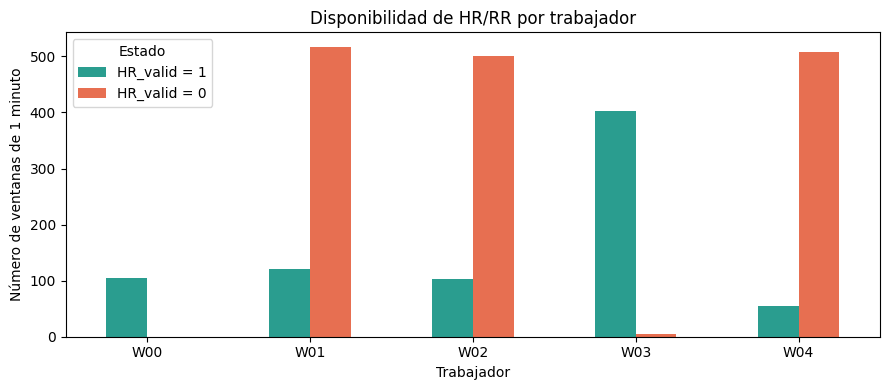

In [10]:
hr_valid_plot = summary.set_index('Trabajador')[['HR_valid = 1', 'HR_valid = 0']]
ax = hr_valid_plot.plot(kind='bar', figsize=(9, 4), color=['#2a9d8f', '#e76f51'])
ax.set_xlabel('Trabajador')
ax.set_ylabel('Número de ventanas de 1 minuto')
ax.set_title('Disponibilidad de HR/RR por trabajador')
ax.legend(title='Estado')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()